# 01 · Select the right model

Before you build an agent, you pick its engine — the **model**. But "best model" is the wrong question. The right question is: *best for **this** task, at what **cost**, **latency**, and **quality**?* A frontier model is amazing and expensive; a mini model is fast and cheap. Great engineers **right-size**.

In this notebook you'll run the *same* task across different models and read the trade-offs straight from the metrics — the exact intuition you'll use in lab 02 when you choose TrailMate's model.

### Learning objectives
By the end of this notebook you'll be able to:
- **Compare** a frontier model (`gpt-5.4`) with a mini model (`gpt-5.4-mini`) on cost and latency.
- **Tune** the **reasoning-effort** lever and see its price.
- **Use** multimodal understanding: have `gpt-5.4` *see* an image and describe it.
- **Chain** models — image understanding (`gpt-5.4`) → image generation (`MAI-Image-2.5-Pro`).
- **Explain** how **Model Router** picks a model per request (the lever you'll pull in lab 02).

> ⏱️ **~30 minutes** · Want to go deeper? The optional `labs/more/` notebooks expand each topic here.


## 1 · Set up and a helper to compare runs

We reuse the same `.env` you validated in notebook 00 — no new setup. Then we define one small helper, `ask(...)`, that sends a prompt and returns not just the answer but the **signals that matter for selection**: latency, token count, and which model actually served the request (important once a router is involved).


In [1]:
import os
import time
from pathlib import Path

from dotenv import load_dotenv
from azure.identity import DefaultAzureCredential
from azure.ai.projects import AIProjectClient


def find_env_file() -> Path:
    """Locate the shared agent-builder/src/.env from anywhere in the tree."""
    for base in [Path.cwd(), *Path.cwd().parents]:
        c = base / "foundry" / "agent-builder" / "src" / ".env"
        if c.exists():
            return c
        if base.name == "agent-builder" and (base / "src" / ".env").exists():
            return base / "src" / ".env"
    raise FileNotFoundError("Run 00-validate-setup first — src/.env not found.")


load_dotenv(find_env_file())
project_client = AIProjectClient(
    endpoint=os.environ["FOUNDRY_PROJECT_ENDPOINT"],
    credential=DefaultAzureCredential(),
)
openai_client = project_client.get_openai_client()


def ask(model: str, prompt: str, reasoning_effort: str | None = None) -> dict:
    """Send one prompt and capture the answer plus cost/latency signals."""
    start = time.perf_counter()

    # Responses API: we talk DIRECTLY to a model deployment — a prompt in, a
    # response out. No instructions, tools, or memory yet; in lab 02 we wrap a
    # model with those to make an *agent* and call it instead. Responses is the
    # newer, recommended Foundry API shape and the only one some models (e.g.
    # Claude) serve. Reasoning effort is passed as reasoning={"effort": ...}.
    extra = {"reasoning": {"effort": reasoning_effort}} if reasoning_effort else {}
    resp = openai_client.responses.create(model=model, input=prompt, **extra)
    elapsed = time.perf_counter() - start
    return {
        "asked_model": model,
        "served_model": resp.model,   # a router may serve a different model
        "latency_s": round(elapsed, 2),
        "total_tokens": getattr(resp.usage, "total_tokens", None),
        "answer": resp.output_text,
    }


print("Ready. `ask(model, prompt)` returns latency, tokens, and the answer.")


Ready. `ask(model, prompt)` returns latency, tokens, and the answer.


## 2 · Capability & cost — frontier vs mini

Same product-launch task, two engines: `gpt-5.4` (frontier) and `gpt-5.4-mini`. The table below reports, for each run:

- **`asked_model`** — the deployment you *called*.
- **`served_model`** — the model that *actually answered*. For a direct model these match; for a **router** (section 5) they can differ.
- **`latency_s`** and **`total_tokens`** — the two numbers that drive speed and cost at scale.
- **`answer_preview`** — the first line of the response, so you can judge quality against cost.

> ❓ **Your call:** For a well-specified, structured task like this JSON spec sheet, does the frontier model earn its extra tokens and latency — or is the mini model good enough? Run the cell and read the table.


In [2]:
import pandas as pd

LAUNCH_TASK = (
    "You're helping launch Contoso Outdoors gear. From the description below, "
    "return a compact JSON object with keys: name, category, key_features (list), "
    "best_for.\n\n"
    "Description: The Alpine Explorer Tent sleeps 8, has a 3000mm rainfly, taped "
    "seams, and a vestibule for storing gear."
)

# Same task, two engines.
runs = [ask("gpt-5.4", LAUNCH_TASK), ask("gpt-5.4-mini", LAUNCH_TASK)]

# One table — read the trade-off across the rows (answer quality vs tokens/latency).
df = pd.DataFrame(runs)
df["answer_preview"] = df["answer"].str.replace("\n", " ").str.slice(0, 90) + "…"
df[["asked_model", "served_model", "latency_s", "total_tokens", "answer_preview"]]


,asked_model,served_model,latency_s,total_tokens,answer_preview
0,gpt-5.4,gpt-5.4,6.13,122,"{""name"":""Alpine Explorer Tent"",""category"":""ten..."
1,gpt-5.4-mini,gpt-5.4-mini,3.40,123,"{""name"":""Alpine Explorer Tent"",""category"":""ten..."


## 3 · The reasoning-effort lever

Reasoning models can **think harder** when a task needs it — at the cost of more tokens and time. The `reasoning_effort` setting (`low` → `high`) is a dial you control. We give `gpt-5.4` an open-ended planning question at both settings and put the results in one table.

> ❓ **Your call:** Compare the `low` and `high` rows. Did the extra tokens at `high` effort produce a genuinely *better* plan (check `answer_preview`), or just a longer one? When is deeper reasoning worth paying for?


In [3]:
REASONING_TASK = (
    "A family of four wants ONE tent for summer car-camping with occasional light "
    "rain. Reason step by step about which specs matter (capacity, season rating, "
    "rainfly, weight) and what to look for. Be thorough."
)

effort_runs = []
for effort in ["low", "high"]:
    try:
        # reasoning_effort trades tokens/latency for deeper thinking.
        effort_runs.append({"effort": effort, **ask("gpt-5.4", REASONING_TASK, reasoning_effort=effort)})
    except Exception as err:
        print(f"reasoning_effort='{effort}' not supported on this deployment ({err}).")

# Read the openings side by side first — the "feel" of the effort shows up in how
# the answer is structured before the table reduces it all to numbers.
for run in effort_runs:
    print(f"===== reasoning_effort = {run['effort'].upper()}  "
          f"({run['latency_s']}s · {run['total_tokens']} tokens) =====")
    print(run["answer"][:600].strip())
    print("…\n")

# Both answers open the same way, so a text preview looks identical — the signal
# that actually differs is length. `answer_chars` = how much more the model wrote.
df = pd.DataFrame(effort_runs)
if not df.empty:
    df["answer_chars"] = df["answer"].str.len()
df[["effort", "latency_s", "total_tokens", "answer_chars"]] if not df.empty else None


===== reasoning_effort = LOW  (34.23s · 3308 tokens) =====
Here’s a practical, step-by-step way for a family of four to choose **one tent for summer car-camping with occasional light rain**.

---

# 1) Start with the camping style: summer + car camping + light rain

This matters because it tells you what **not** to overpay for.

Since this is:

- **summer camping**
- **car camping** (not backpacking)
- **occasional light rain**, not storms or winter conditions

the tent should prioritize:

- **comfort and space**
- **good airflow**
- **easy setup**
- **basic rain protection**
- **durability good enough for repeated family use**

You do **not** need:
…

===== reasoning_effort = HIGH  (35.04s · 3785 tokens) =====
For a **family of four doing summer car-camping with occasional light rain**, the “best” tent is usually **not** the lightest or the most extreme-weather model. The right tent is one that is:

- **roomy enough to be comfortable**
- **ventilated enough for warm weather**
- **weat

,effort,latency_s,total_tokens,answer_chars
0,low,34.23,3308,14090
1,high,35.04,3785,13744


## 4 · Multimodal chat — image understanding

`gpt-5.4` isn't limited to text — it can **see**. Here we hand it the *real* Alpine Explorer Tent catalog photo and give it two jobs: **describe** what's in the image, and **write a detailed prompt** that could recreate it with an image-generation model.

Keep an eye on that recreation prompt — in the next section we feed it to an image *generator* and compare the result with this original. This is also your first taste of **chaining models**: one model's output becomes another's input.


The real product image we'll analyze:


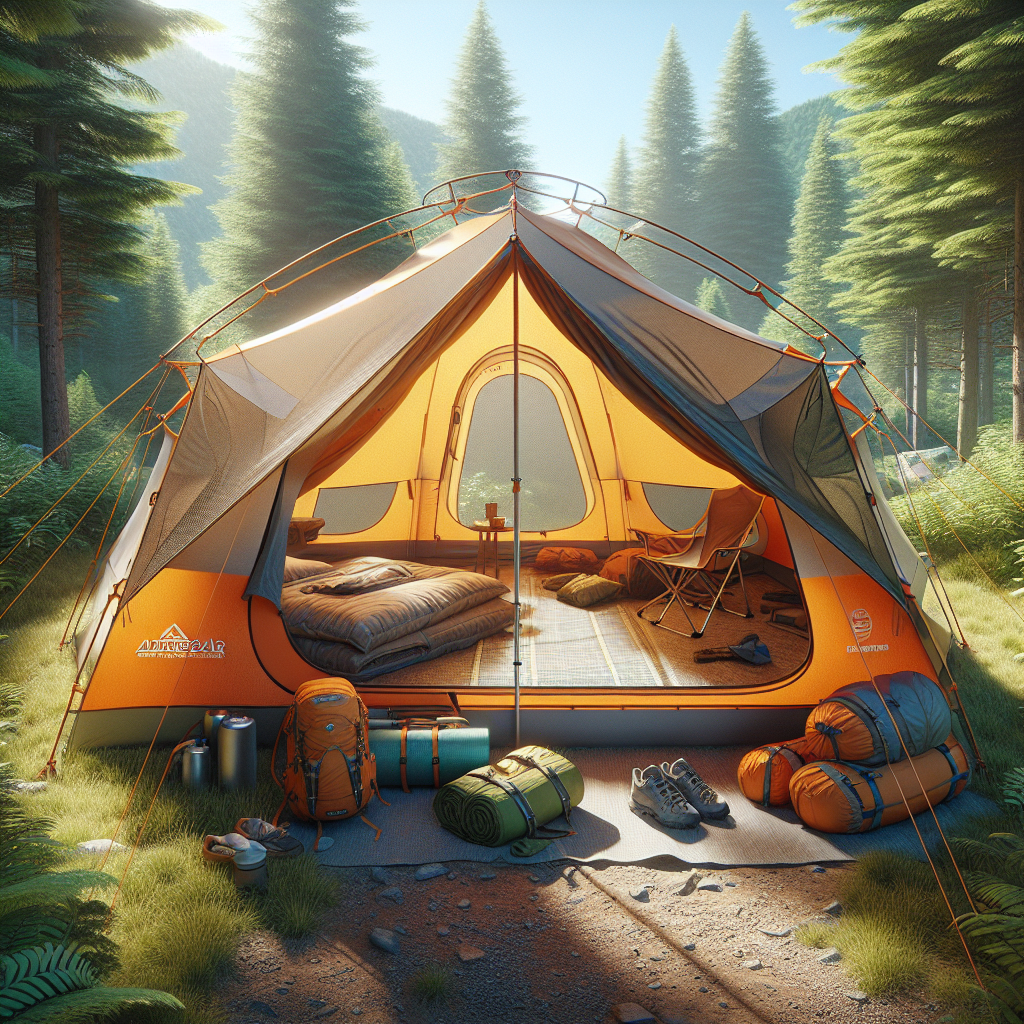


📝 Description:
 A front-facing product photo of an orange and gray Alpine Explorer camping tent set up in a sunlit forest clearing surrounded by tall evergreen trees and hazy mountain light. The tent is fully pitched with guy lines and mesh outer panels pulled open to reveal a warm glowing interior. Inside are sleeping pads, blankets, pillows, and a folding camp chair on a woven floor mat. In front of the tent entrance are neatly arranged camping items including an orange backpack, metal bottles, a rolled sleeping pad, a green foam mat, gray hiking shoes, and two orange-and-blue packed sleeping bags. The scene is symmetrical, bright, and inviting, with soft morning sunlight filtering through the trees and illuminating the tent fabric.

🎯 Recreation prompt (feeds the generator in section 5):
 Create a highly realistic outdoor product photo of a large modern camping tent called the Alpine Explorer Tent, centered in the frame and viewed straight-on from the entrance. The tent is pitched 

In [4]:
import base64
import json

from IPython.display import Image, display

# gpt-5.4 can SEE images (image understanding). We give it the REAL Alpine
# Explorer catalog photo and ask it to (1) describe it and (2) write a prompt to
# recreate it — that prompt becomes the input to the image GENERATOR in section 5.
AB = find_env_file().parent.parent                      # .../foundry/agent-builder
IMAGE_PATH = AB / "assets" / "products" / "alpine-explorer-tent.png"

print("The real product image we'll analyze:")
display(Image(filename=str(IMAGE_PATH)))

# Send the image inline (base64 data URL) alongside the text task, via the
# Responses API. Image goes BEFORE the text — safe for GPT, and required for
# Claude-style vision models that ignore an image placed after a long prompt.
img_b64 = base64.b64encode(IMAGE_PATH.read_bytes()).decode()
resp = openai_client.responses.create(
    model="gpt-5.4",
    input=[{
        "role": "user",
        "content": [
            {"type": "input_image", "image_url": f"data:image/png;base64,{img_b64}"},
            {"type": "input_text", "text": (
                "This is the Alpine Explorer Tent product photo. Return ONLY a JSON "
                "object with two keys: 'description' (what the image shows) and "
                "'recreation_prompt' (a detailed text-to-image prompt that would "
                "recreate this exact image)."
            )},
        ],
    }],
)
answer = resp.output_text

# Pull the recreation prompt out of the JSON (fall back to raw text if needed).
try:
    parsed = json.loads(answer[answer.find("{"): answer.rfind("}") + 1])
    RECREATION_PROMPT = parsed["recreation_prompt"]
    print("\n📝 Description:\n", parsed["description"])
    print("\n🎯 Recreation prompt (feeds the generator in section 5):\n", RECREATION_PROMPT)
except Exception:
    RECREATION_PROMPT = answer
    print("\nModel output:\n", answer)


## 5 · Image generation — chaining & prompt refinement

We used `gpt-5.4` to *understand* the real photo and write a detailed recreation prompt. Now let's generate — in two steps:

1. **Ask `gpt-5.4` to "generate an image."** It's a *language* model, so it can't emit pixels — and it usually won't even say *"I can't."* It quietly pivots to handing you **text** (a prompt). That silent pivot **is** the capability boundary: it does the language thing because it can't do the pixel thing.
2. **Use `MAI-Image-2.5-Pro` twice** — once with a **naive one-line prompt**, once with the **detailed recreation prompt** `gpt-5.4` wrote from the real photo — and view them **side by side**. This shows how chaining a vision model to *refine the task* produces a better image.

> 🔎 **Note:** MAI uses a **dedicated endpoint** (`/mai/v1/images/generations`), not the OpenAI chat route.

> 👀 **Observe (image "truth"):** Even the refined image won't perfectly match the real product — an *ungrounded* generator invents details. Same grounding lesson as file-search in lab 02, a problem worth solving another day.


In [5]:
# gpt-5.4 is a LANGUAGE model — it can't emit pixels. Ask it to "generate an
# image" and watch what actually comes back: not an image, and usually not even
# an "I can't" — it quietly pivots to handing you a TEXT prompt instead. That
# silent pivot IS the capability boundary: it does the language thing (write a
# prompt) because it literally cannot do the pixel thing.
image_attempt = openai_client.responses.create(
    model="gpt-5.4",
    input="Generate an image of the Alpine Explorer Tent for a product catalog.",
)
print("🗣️ We asked gpt-5.4 to GENERATE an image. What came back is TEXT, not pixels:\n")
print(image_attempt.output_text)
print("\n👀 Notice: it didn't return an image — and it may not even say \"I can't\". "
      "It just handed us a prompt.")
print("➡️ That's the boundary. The next cell sends a prompt to MAI-Image-2.5-Pro for real pixels.")


🗣️ We asked gpt-5.4 to GENERATE an image. What came back is TEXT, not pixels:

Sure — please upload a reference image of the Alpine Explorer Tent, or describe the tent’s appearance, color, angles, background, and catalog style you want.

If you want, I can also help you craft a clean product-image prompt, for example:

**Prompt:**
“Studio product photo of an Alpine Explorer Tent, fully assembled, modern outdoor camping tent, premium materials, realistic fabric texture, front three-quarter view, isolated on a pure white background, soft even lighting, subtle natural shadows, high detail, commercial product catalog style, sharp focus, no people, no props, centered composition.”

If you give me the tent details, I can make this much more accurate.

👀 Notice: it didn't return an image — and it may not even say "I can't". It just handed us a prompt.
➡️ That's the boundary. The next cell sends a prompt to MAI-Image-2.5-Pro for real pixels.


Generating two images with MAI-Image-2.5-Pro (each call takes ~10-20s)…



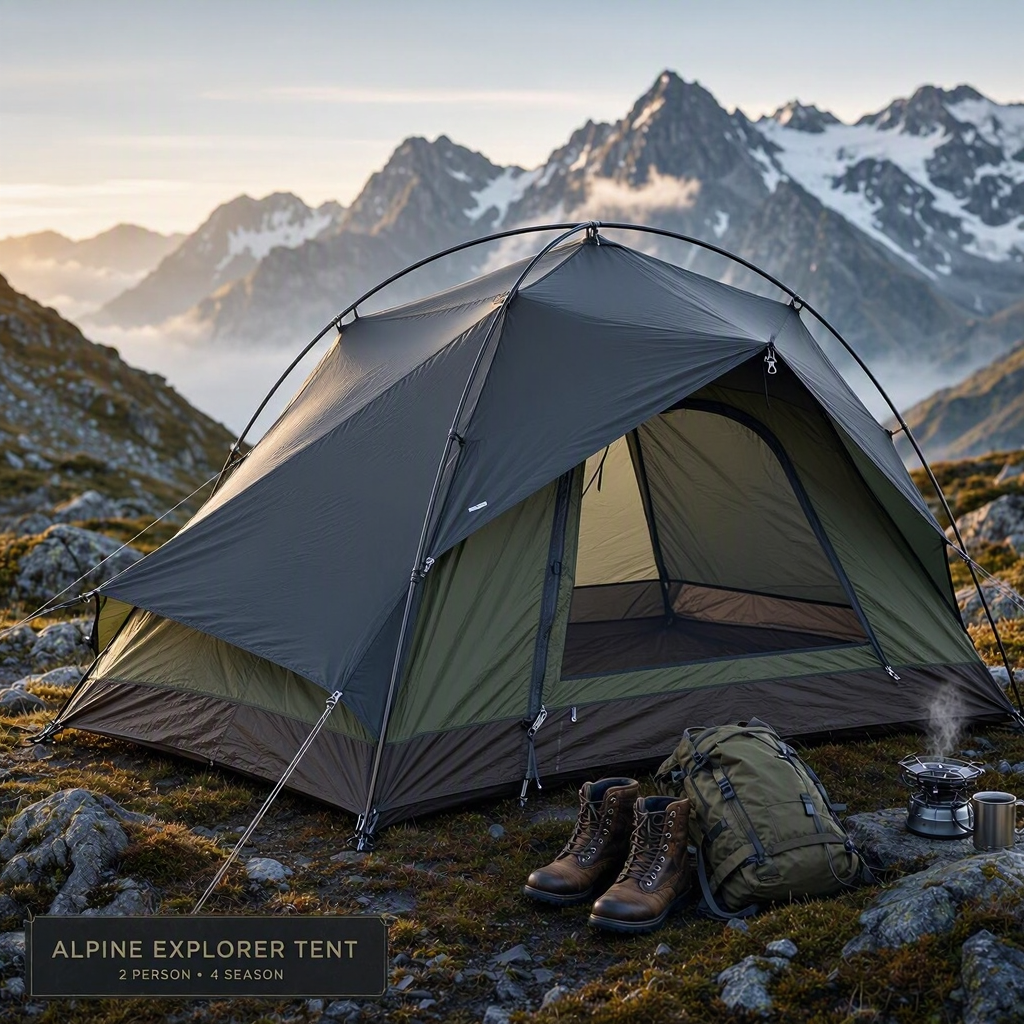
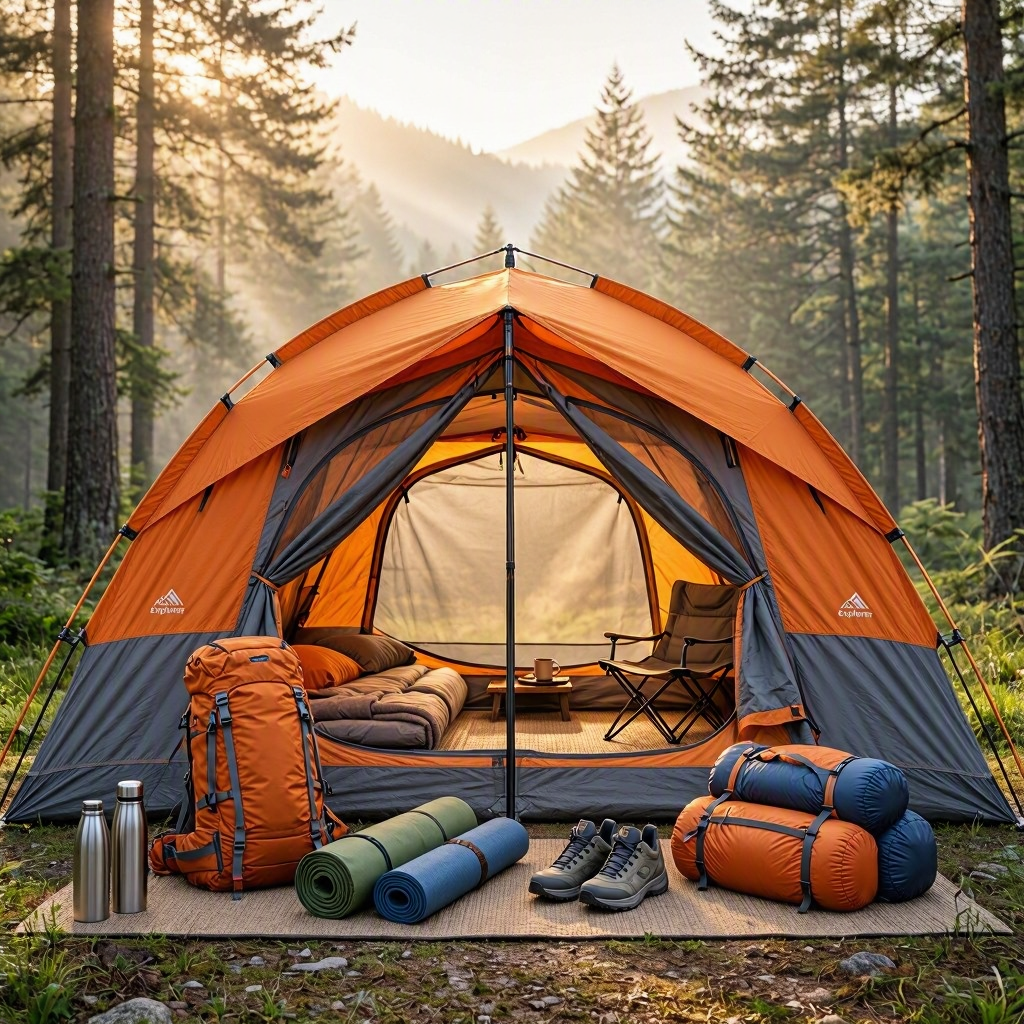

Left = naive one-liner · Right = detailed prompt chained from gpt-5.4's vision.
Chaining a vision model to refine the task gives the generator far more to work with.


In [6]:
import base64
from urllib.parse import urlparse

import requests
from azure.identity import DefaultAzureCredential
from IPython.display import HTML, display

# Step 2 — switch to MAI (a dedicated image model on its own endpoint) and run it
# TWICE: a naive one-liner vs the detailed prompt gpt-5.4 wrote from the real
# photo in section 4 (RECREATION_PROMPT). Same subject, very different detail.
resource = urlparse(os.environ["FOUNDRY_PROJECT_ENDPOINT"])
mai_url = f"{resource.scheme}://{resource.netloc}/mai/v1/images/generations"
token = DefaultAzureCredential().get_token("https://cognitiveservices.azure.com/.default").token


def generate_image(prompt: str) -> str:
    """Call MAI and return the generated image as a base64 PNG string."""
    r = requests.post(
        mai_url,
        headers={"Content-Type": "application/json", "Authorization": f"Bearer {token}"},
        json={"model": "MAI-Image-2.5-Pro", "prompt": prompt, "width": 1024, "height": 1024},
        timeout=120,
    )
    r.raise_for_status()
    return r.json()["data"][0]["b64_json"]


DEFAULT_PROMPT = "A product photo of the Alpine Explorer Tent."
# The "refined" side uses the prompt gpt-5.4 wrote from the real photo in section 4.
REFINED_PROMPT = globals().get("RECREATION_PROMPT", DEFAULT_PROMPT)

print("Generating two images with MAI-Image-2.5-Pro (each call takes ~10-20s)…")
try:
    img_default = generate_image(DEFAULT_PROMPT)
    img_refined = generate_image(REFINED_PROMPT)
    display(HTML(f"""
    <div style="display:flex;gap:20px;text-align:center">
      <figure style="margin:0">
        <img src="data:image/png;base64,{img_default}" width="360"/>
        <figcaption><b>Naive prompt</b><br/><small>"{DEFAULT_PROMPT}"</small></figcaption>
      </figure>
      <figure style="margin:0">
        <img src="data:image/png;base64,{img_refined}" width="360"/>
        <figcaption><b>Refined prompt</b><br/><small>written by gpt-5.4 from the real photo</small></figcaption>
      </figure>
    </div>"""))
    print("Left = naive one-liner · Right = detailed prompt chained from gpt-5.4's vision.")
    print("Chaining a vision model to refine the task gives the generator far more to work with.")
except Exception as err:
    print(f"Image generation call failed ({err}).")
    print("You can also try MAI-Image-2.5-Pro in the Foundry portal → Images playground.")


## 6 · Let the router decide — Model Router

What if you didn't have to choose per request? **Model Router** looks at each prompt and routes it to an appropriately sized model — cheap ones for easy asks, stronger ones for hard ones. Because you call one `model-router` deployment but a *different* model may answer, this is where **`asked_model`** and **`served_model`** come apart.

> ❓ **Your call:** In the table, compare `served_model` for the **simple** vs **complex** prompt. Did the router send them to different models? Would you have picked the same way by hand? This is exactly the lever you'll pull for TrailMate v2 in lab 02.


In [7]:
SIMPLE = "In one sentence, what is the capital of France?"
COMPLEX = (
    "Plan a 3-day, 2-night backpacking trip for two in the Cascades in early "
    "autumn. Consider weather, gear, food, and safety, and lay out a day-by-day "
    "plan with your reasoning."
)

router_runs = []
for label, prompt in [("simple", SIMPLE), ("complex", COMPLEX)]:
    r = ask("model-router", prompt)
    r["ask"] = label
    router_runs.append(r)

# One table — did asked (model-router) and served (the chosen model) diverge?
pd.DataFrame(router_runs)[["ask", "asked_model", "served_model", "latency_s", "total_tokens"]]


,ask,asked_model,served_model,latency_s,total_tokens
0,simple,model-router,gpt-5-mini-2025-08-07,3.52,43
1,complex,model-router,grok-4-1-fast-reasoning,16.09,2906


## 🧭 Summary — so, how do I pick a model?

You just built the core intuition for model selection:

| Signal | What you saw | Why it matters |
|---|---|---|
| **Capability** | frontier vs mini on the same task | Only pay for capability the task needs |
| **Cost** | token counts side by side | Tokens ≈ money at scale |
| **Latency** | seconds per call | User experience and throughput |
| **Reasoning effort** | `low` vs `high` token cost | Spend "thinking" only where it changes the answer |
| **Multimodal** | `gpt-5.4` *sees* and describes an image | Some tasks need vision, not just text |
| **Chaining** | vision prompt → `MAI-Image-2.5-Pro` | Combine specialized models; each does what it's best at |
| **Model Router** | one endpoint, different served models | Right-size *per request*, automatically |

**Two takeaways:**
1. There's no single "best" model — there's the best model *for this task, cost, and latency*. Model Router lets you defer that choice to runtime (TrailMate's first optimization lever).
2. **Grounding matters for images too.** The generated tent didn't match the real product — an *ungrounded* image. Just like text answers need file-search grounding (lab 02), images need grounding to reflect reality.

### Next
➡️ Open **[02 · Build, evaluate & optimize the agent](02-agent-optimization.ipynb)** — where you'll build TrailMate, measure a baseline, and hill-climb with Model Router and Agent Optimizer.
